# Projeto Fundamentos de Machine Learning com Scikit-Learn

- Projeto no [Github](https://github.com/deyvisonramos/fundamento_ml)
- Dataset escolhido: [**Bank Marketing (Kaggle)**](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset). Objetivo: prever se um cliente vai aderir a um depósito a prazo (`deposit=yes/no`) a partir de dados demográficos, financeiros e histórico da campanha.

## 1. Setup e Imports

O projeto usa `pandas`, `numpy`, `scikit-learn`, `matplotlib` e `seaborn`. Todos os modelos apresentados foram construídos com `scikit-learn`.

In [41]:
from dataclasses import dataclass
from typing import Any
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, RobustScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
TARGET_COLUMN = "deposit"
POSITIVE_LABEL = "yes"
CV_SPLITS = 3
NUMERIC_FEATURES = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
CATEGORICAL_FEATURES = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

@dataclass
class ModelArtifacts:
    name: str
    estimator: Any
    train_metrics: dict[str, float]
    test_metrics: dict[str, float]
    fit_seconds: float
    classification_report_test: dict[str, Any]
    confusion_matrix_test: list[list[int]]
    positive_scores_test: list[float]
    positive_predictions_test: list[int]
    best_params: dict[str, Any] | None = None
    cv_summary: dict[str, Any] | None = None


## 2. Funções Auxiliares e Utilitários

Funções compartilhadas entre as seções do notebook ficam aqui.

In [42]:
def load_dataset(csv_path: str = "dataset/bank.csv") -> pd.DataFrame:
    return pd.read_csv(csv_path)

def encode_target(df: pd.DataFrame) -> pd.Series:
    return (df[TARGET_COLUMN] == POSITIVE_LABEL).astype(int)

def split_dataset(df: pd.DataFrame):
    X = df.drop(columns=[TARGET_COLUMN])
    y = encode_target(df)
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

def build_numeric_transformer(scale: bool = True) -> Pipeline:
    steps: list[tuple[str, Any]] = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.extend([("power", PowerTransformer()), ("scaler", RobustScaler())])
    return Pipeline(steps)

def build_categorical_transformer() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ])

def build_preprocessor(scale_numeric: bool = True) -> ColumnTransformer:
    return ColumnTransformer([
        ("num", build_numeric_transformer(scale=scale_numeric), NUMERIC_FEATURES),
        ("cat", build_categorical_transformer(), CATEGORICAL_FEATURES),
    ])

def get_positive_scores(estimator: Any, X: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X)
        if getattr(scores, "ndim", 1) > 1:
            scores = scores[:, 1]
        return 1.0 / (1.0 + np.exp(-scores))
    return np.asarray(estimator.predict(X), dtype=float)

def calculate_metrics(y_true: pd.Series, predictions: np.ndarray, scores: np.ndarray) -> dict[str, float]:
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, scores)
    return {"accuracy": accuracy_score(y_true, predictions), "precision": precision_score(y_true, predictions, zero_division=0), "recall": recall_score(y_true, predictions, zero_division=0), "f1": f1_score(y_true, predictions, zero_division=0), "roc_auc": roc_auc_score(y_true, scores), "pr_auc": auc(recall_curve, precision_curve)}

def fit_and_evaluate(name: str, estimator: Any, X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series, y_test: pd.Series, best_params: dict[str, Any] | None = None, cv_summary: dict[str, Any] | None = None) -> ModelArtifacts:
    started = time.perf_counter()
    estimator.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started
    train_predictions = estimator.predict(X_train)
    test_predictions = estimator.predict(X_test)
    train_scores = get_positive_scores(estimator, X_train)
    test_scores = get_positive_scores(estimator, X_test)
    return ModelArtifacts(
        name=name,
        estimator=estimator,
        train_metrics=calculate_metrics(y_train, train_predictions, train_scores),
        test_metrics=calculate_metrics(y_test, test_predictions, test_scores),
        fit_seconds=fit_seconds,
        classification_report_test=classification_report(y_test, test_predictions, output_dict=True, zero_division=0),
        confusion_matrix_test=confusion_matrix(y_test, test_predictions).tolist(),
        positive_scores_test=test_scores.tolist(),
        positive_predictions_test=test_predictions.tolist(),
        best_params=best_params,
        cv_summary=cv_summary,
    )

def summarize_dataset(df: pd.DataFrame) -> dict[str, Any]:
    return {"shape": [int(df.shape[0]), int(df.shape[1])], "target_distribution": df[TARGET_COLUMN].value_counts().astype(int).to_dict(), "describe_numeric": df[NUMERIC_FEATURES].describe().round(3).to_dict(), "categorical_value_counts": {column: df[column].value_counts().head(10).astype(int).to_dict() for column in CATEGORICAL_FEATURES}, "null_counts": df.isnull().sum().astype(int).to_dict()}

def plot_confusion(matrix: list[list[int]], model_name: str):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusão - {model_name}")
    plt.show()

def get_feature_importance_df(artifact: ModelArtifacts, X_test: pd.DataFrame, y_test: pd.Series, top_n: int = 15) -> pd.DataFrame:
    model = artifact.estimator
    if "selector" in model.named_steps:
        feature_names = model.named_steps["preprocessor"].get_feature_names_out()
        selected_mask = model.named_steps["selector"].get_support()
        feature_names = feature_names[selected_mask]
        estimator = model.named_steps[list(model.named_steps.keys())[-1]]
    else:
        feature_names = model.named_steps["preprocessor"].get_feature_names_out()
        estimator = model.named_steps[list(model.named_steps.keys())[-1]]
    if hasattr(estimator, "feature_importances_"):
        importances = estimator.feature_importances_
    else:
        transformed = model.named_steps["preprocessor"].transform(X_test)
        if "selector" in model.named_steps:
            transformed = model.named_steps["selector"].transform(transformed)
        result = permutation_importance(estimator, transformed, y_test, n_repeats=5, random_state=RANDOM_STATE, scoring="f1")
        importances = result.importances_mean
    return pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False).head(top_n)

def plot_feature_importance(artifact: ModelArtifacts, X_test: pd.DataFrame, y_test: pd.Series, top_n: int = 15):
    importance_df = get_feature_importance_df(artifact, X_test, y_test, top_n=top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=importance_df, x="importance", y="feature", hue="feature", dodge=False, palette="Blues_r", ax=ax)
    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_title(f"Top features - {artifact.name}")
    plt.show()
    return importance_df

def summarize_cv(search: Any, top_n: int = 5) -> dict[str, Any]:
    results = pd.DataFrame(search.cv_results_)
    top = results.sort_values("rank_test_score").head(top_n)
    return {"best_score": float(search.best_score_), "best_params": search.best_params_, "top_results": top[["rank_test_score", "mean_test_score", "std_test_score", "params"]].to_dict(orient="records")}

def run_random_and_grid_search(pipeline: Pipeline, random_params: dict[str, Any], grid_builder, X_train: pd.DataFrame, y_train: pd.Series, scoring: str, n_iter: int):
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    random_search = RandomizedSearchCV(estimator=clone(pipeline), param_distributions=random_params, n_iter=n_iter, scoring=scoring, cv=cv, random_state=RANDOM_STATE, n_jobs=1, refit=True)
    random_search.fit(X_train, y_train)
    grid_search = GridSearchCV(estimator=clone(pipeline), param_grid=grid_builder(random_search.best_params_), scoring=scoring, cv=cv, n_jobs=1, refit=True)
    grid_search.fit(X_train, y_train)
    return grid_search, {"random_search": summarize_cv(random_search), "grid_search": summarize_cv(grid_search)}

def get_perceptron_coefficients(artifact: ModelArtifacts) -> pd.DataFrame:
    pipeline = artifact.estimator
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefs = pipeline.named_steps["perceptron"].coef_[0]
    return pd.DataFrame({"feature": feature_names, "coefficient": coefs, "abs_coefficient": np.abs(coefs)}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

def get_tree_rules(artifact: ModelArtifacts, max_depth: int = 3) -> str:
    pipeline = artifact.estimator
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    tree = pipeline.named_steps["dt"]
    return export_text(tree, feature_names=list(feature_names), max_depth=max_depth)

def prepare_voting_classifier(best_svm: Pipeline, best_rf: Pipeline) -> VotingClassifier:
    log_reg_pipe = Pipeline([("preprocessor", build_preprocessor(scale_numeric=True)), ("logreg", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced"))])
    return VotingClassifier(estimators=[("svm", clone(best_svm)), ("rf", clone(best_rf)), ("logreg", log_reg_pipe)], voting="hard", n_jobs=1)

def plot_model_curves(y_test: pd.Series, artifacts: list[ModelArtifacts]):
    fig, ax = plt.subplots(figsize=(8, 6))
    for artifact in artifacts:
        fpr, tpr, _ = roc_curve(y_test, artifact.positive_scores_test)
        ax.plot(fpr, tpr, label=f"{artifact.name} (AUC={artifact.test_metrics['roc_auc']:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Curvas ROC")
    ax.legend(fontsize=8)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))
    for artifact in artifacts:
        precision, recall, _ = precision_recall_curve(y_test, artifact.positive_scores_test)
        ax.plot(recall, precision, label=f"{artifact.name} (AUC={artifact.test_metrics['pr_auc']:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Curvas Precision-Recall")
    ax.legend(fontsize=8)
    plt.show()

def collect_model_rows(artifacts: list[ModelArtifacts]) -> pd.DataFrame:
    rows = []
    for artifact in artifacts:
        row = {"model": artifact.name, "fit_seconds": artifact.fit_seconds}
        row.update({f"train_{k}": v for k, v in artifact.train_metrics.items()})
        row.update({f"test_{k}": v for k, v in artifact.test_metrics.items()})
        rows.append(row)
    return pd.DataFrame(rows).sort_values("test_f1", ascending=False)

def build_perceptron_pipeline() -> Pipeline:
    return Pipeline([("preprocessor", build_preprocessor(scale_numeric=True)), ("perceptron", Perceptron(random_state=RANDOM_STATE))])

def build_decision_tree_pipeline() -> Pipeline:
    return Pipeline([("preprocessor", build_preprocessor(scale_numeric=False)), ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE))])

def build_svm_pipeline() -> Pipeline:
    return Pipeline([("preprocessor", build_preprocessor(scale_numeric=True)), ("svc", SVC(probability=False, random_state=RANDOM_STATE))])

def build_rf_pipeline() -> Pipeline:
    return Pipeline([("preprocessor", build_preprocessor(scale_numeric=False)), ("selector", SelectKBest(score_func=f_classif, k="all")), ("rf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))])

def build_gradient_boosting_pipeline() -> Pipeline:
    return Pipeline([("preprocessor", build_preprocessor(scale_numeric=False)), ("selector", SelectKBest(score_func=f_classif, k="all")), ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE))])

## 3. Introdução e Descrição do Problema

O problema é de **classificação binária supervisionada**: prever `deposit` com base em 16 features. Machine learning faz sentido porque a propensão de adesão depende de combinações não triviais entre perfil do cliente, histórico de contato, saldo e contexto da campanha. Regras fixas não capturam bem esses padrões.

Contexto real: campanhas de marketing bancário precisam decidir quem priorizar para contato, equilibrando taxa de conversão, custo operacional e explicabilidade da decisão.

Desafios principais:
- custo assimétrico: falso negativo perde um cliente potencial; falso positivo gera custo operacional
- mistura de variáveis numéricas e categóricas
- presença de `unknown` em várias categóricas
- `pdays = -1` indica ausência de contato anterior
- `duration` merece discussão por potencial leakage, pois só existe após a ligação

In [43]:
df = load_dataset()
summary = summarize_dataset(df)
X_train, X_test, y_train, y_test = split_dataset(df)

print("Forma do dataset:", tuple(summary["shape"]))
print("Distribuição do target:", summary["target_distribution"])
print("Features numéricas:", len(NUMERIC_FEATURES))
print("Features categóricas:", len(CATEGORICAL_FEATURES))

df.head()

Forma do dataset: (11162, 17)
Distribuição do target: {'no': 5873, 'yes': 5289}
Features numéricas: 7
Features categóricas: 9


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 4. Carregamento e Exploração dos Dados (EDA)

Origem dos dados: [**Bank Marketing Dataset**](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset), problema real de adesão a depósito a prazo em campanhas bancárias. A variável-alvo `deposit` foi formulada como classificação binária porque o resultado de negócio tem duas classes mutuamente exclusivas: aderiu (`yes`) ou não aderiu (`no`).

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [45]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11162.0,NaN,NaN,NaN,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
job,11162,12,management,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,11162,3,married,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,11162,4,secondary,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,11162,2,no,10994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,11162.0,NaN,NaN,NaN,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
housing,11162,2,no,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,11162,2,no,9702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,11162,3,cellular,8042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,11162.0,NaN,NaN,NaN,15.658036,8.42074,1.0,8.0,15.0,22.0,31.0


In [46]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

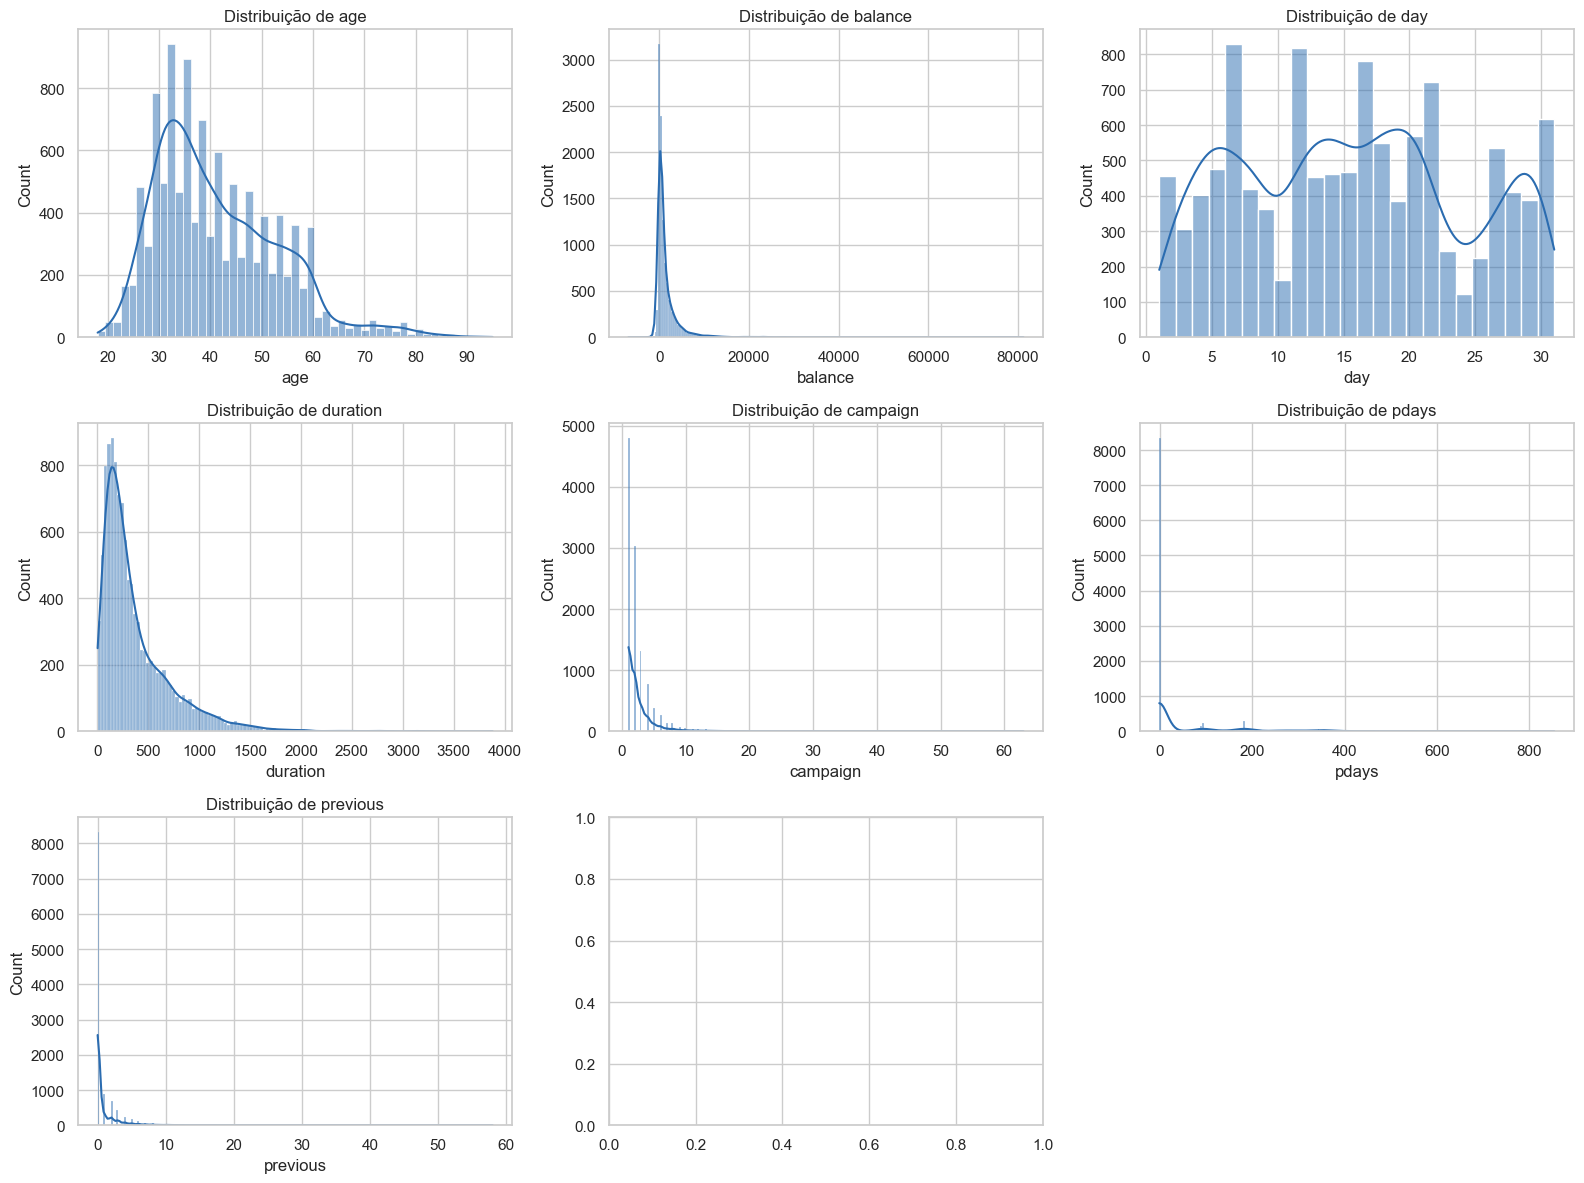

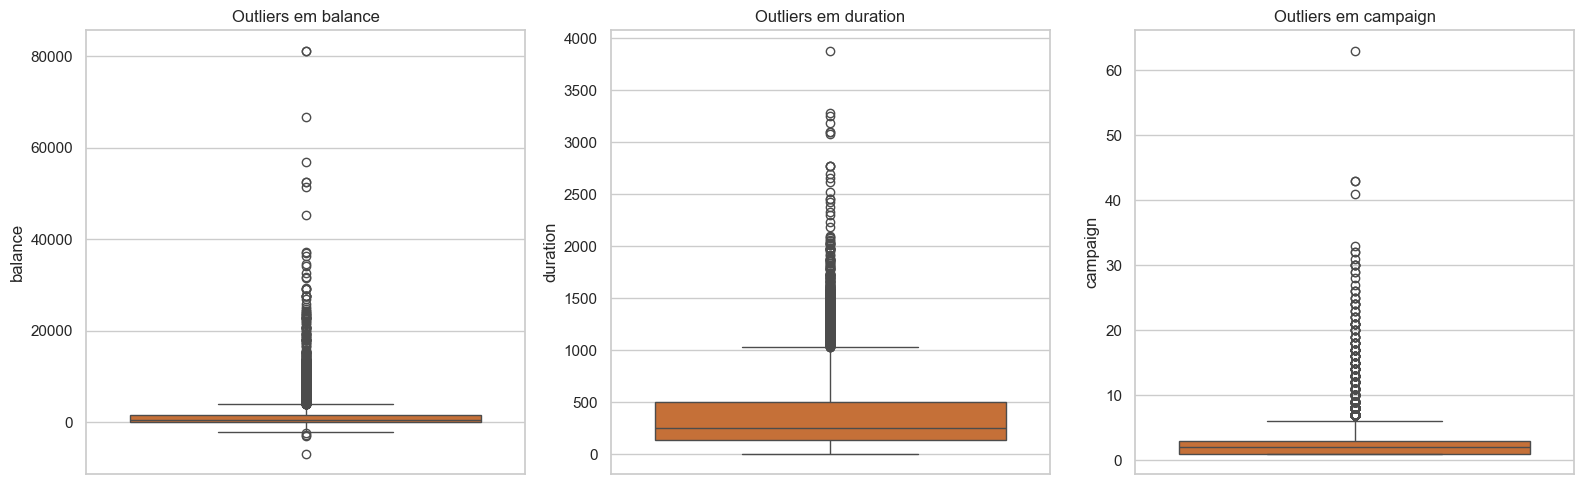

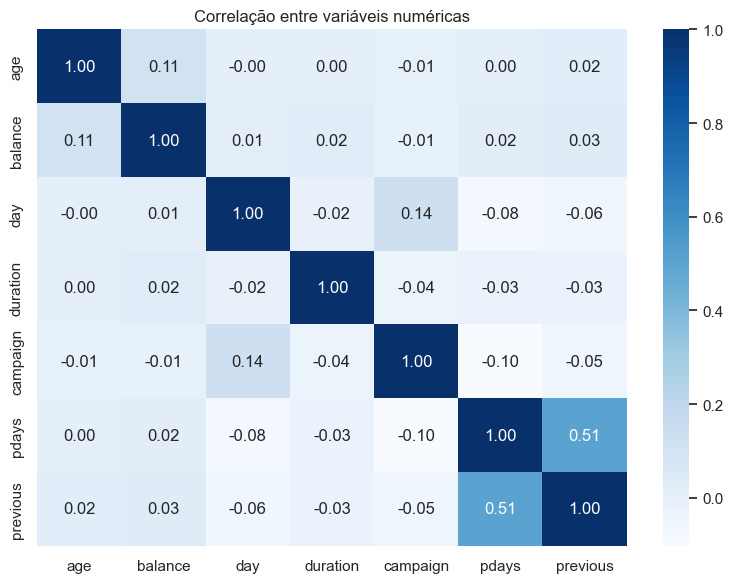

In [47]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for idx, column in enumerate(NUMERIC_FEATURES):
    sns.histplot(df[column], kde=True, ax=axes[idx], color="#2b6cb0")
    axes[idx].set_title(f"Distribuição de {column}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, column in zip(axes, ["balance", "duration", "campaign"], strict=True):
    sns.boxplot(y=df[column], ax=ax, color="#dd6b20")
    ax.set_title(f"Outliers em {column}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[NUMERIC_FEATURES].corr(), annot=True, cmap="Blues", fmt=".2f", ax=ax)
ax.set_title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

Discussão da feature `duration`: ela melhora bastante a capacidade preditiva, mas pode introduzir leakage se o objetivo real for decidir **antes** da ligação terminar. Para um sistema operacional em tempo real, seria recomendável treinar uma segunda versão sem essa variável.

## 5. Pre-processamento

O pipeline separa treino/teste antes de qualquer transformação e usa `ColumnTransformer`:
- numéricas: `SimpleImputer(median)` + `PowerTransformer` + `RobustScaler` para modelos sensíveis a escala
- categóricas: `SimpleImputer(most_frequent)` + `OneHotEncoder(drop='first', handle_unknown='ignore')`

Para árvores e ensembles baseados em árvore, o escalonamento numérico é removido, mantendo imputação e codificação.

In [48]:
NUMERIC_FEATURES, CATEGORICAL_FEATURES, build_preprocessor()

(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'],
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'poutcome'],
 ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('power', PowerTransformer()),
                                                  ('scaler', RobustScaler())]),
                                  ['age', 'balance', 'day', 'duration',
                                   'campaign', 'pdays', 'previous']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('encoder',
                                                   OneHotEncoder(

## 6. Modelo Baseline: Perceptron

O Perceptron foi escolhido como baseline linear por ser simples, interpretável e barato. Se ele não conseguir modelar bem o problema, isso sugere não linearidade e necessidade de modelos flexíveis. Neste baseline não foi usada validação cruzada, preservando um ponto de comparação direto sobre um único split treino/teste.

In [49]:
perceptron_artifact = fit_and_evaluate("Perceptron Baseline", build_perceptron_pipeline(), X_train, X_test, y_train, y_test)
coef_df = get_perceptron_coefficients(perceptron_artifact)
perceptron_bias = float(perceptron_artifact.estimator.named_steps["perceptron"].intercept_[0])
coef_df.head(15)

,feature,coefficient,abs_coefficient
0,num__duration,10.573803,10.573803
1,cat__month_dec,7.000000,7.000000
2,cat__month_may,-6.000000,6.000000
3,cat__poutcome_success,6.000000,6.000000
4,cat__job_student,5.000000,5.000000
5,cat__month_jul,-5.000000,5.000000
6,cat__month_mar,5.000000,5.000000
7,cat__month_oct,5.000000,5.000000
8,cat__job_self-employed,-4.000000,4.000000
9,cat__contact_unknown,-4.000000,4.000000


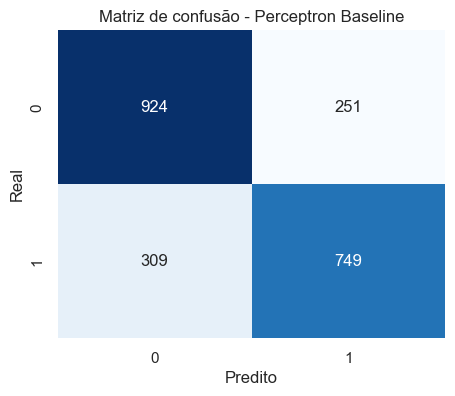

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.749,0.749,0.708,0.728,0.83,0.777


In [50]:
plot_confusion(perceptron_artifact.confusion_matrix_test, perceptron_artifact.name)
pd.DataFrame([perceptron_artifact.test_metrics]).round(3)

Na prática, o baseline serve como referência mínima para os modelos seguintes. Os coeficientes de maior magnitude indicam as variáveis que mais deslocam o hiperplano.

In [51]:
print({"perceptron_bias": perceptron_bias})
coef_df[["feature", "coefficient"]].head(10)

{'perceptron_bias': -0.010000000000000004}


,feature,coefficient
0,num__duration,10.573803
1,cat__month_dec,7.000000
2,cat__month_may,-6.000000
3,cat__poutcome_success,6.000000
4,cat__job_student,5.000000
5,cat__month_jul,-5.000000
6,cat__month_mar,5.000000
7,cat__month_oct,5.000000
8,cat__job_self-employed,-4.000000
9,cat__contact_unknown,-4.000000


O bias desloca o hiperplano em relação à origem, enquanto os pesos controlam sua orientação. Features com coeficientes positivos empurram a decisão para a classe `yes`; coeficientes negativos fazem o oposto. Como o modelo fica abaixo das melhores abordagens não lineares, isso indica underfitting parcial e confirma a limitação do Perceptron em fronteiras não linearmente separáveis, além de sensibilidade a ruído e outliers.

## 7. Modelo com Árvore de Decisão

A árvore permite fronteiras não lineares e regras explícitas do tipo if-then-else. Também permite discutir overfitting comparando treino e teste.

In [52]:
decision_tree_artifact = fit_and_evaluate("Decision Tree Default", build_decision_tree_pipeline(), X_train, X_test, y_train, y_test)

def tree_grid(best_params: dict[str, Any]) -> dict[str, list[Any]]:
    best_depth = best_params.get("dt__max_depth") or 10
    best_split = best_params.get("dt__min_samples_split", 2)
    best_leaf = best_params.get("dt__min_samples_leaf", 1)
    return {
        "dt__criterion": [best_params["dt__criterion"]],
        "dt__max_depth": sorted({max(2, best_depth - 2), best_depth, best_depth + 2}),
        "dt__min_samples_split": sorted({2, max(2, best_split - 2), best_split, best_split + 2}),
        "dt__min_samples_leaf": sorted({1, max(1, best_leaf - 1), best_leaf, best_leaf + 1}),
        "dt__max_features": [best_params["dt__max_features"]],
        "dt__class_weight": [best_params["dt__class_weight"]],
    }

tree_search, tree_cv_summary = run_random_and_grid_search(
    pipeline=build_decision_tree_pipeline(),
    random_params={
        "dt__criterion": ["gini", "entropy", "log_loss"],
        "dt__max_depth": [2, 3, 5, 7, 10, 15],
        "dt__min_samples_split": [2, 5, 10, 20],
        "dt__min_samples_leaf": [1, 2, 5, 10],
        "dt__max_features": ["sqrt", "log2", None],
        "dt__class_weight": [None, "balanced"],
    },
    grid_builder=tree_grid,
    X_train=X_train,
    y_train=y_train,
    scoring="f1",
    n_iter=8,
)

decision_tree_tuned_artifact = fit_and_evaluate("Decision Tree Tuned", tree_search.best_estimator_, X_train, X_test, y_train, y_test, best_params=tree_search.best_params_, cv_summary=tree_cv_summary)
tree_rules_text = get_tree_rules(decision_tree_tuned_artifact)
metrics_tree = collect_model_rows([perceptron_artifact, decision_tree_artifact, decision_tree_tuned_artifact])
metrics_tree.round(3)

,model,fit_seconds,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,train_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
2,Decision Tree Tuned,0.117,0.876,0.848,0.899,0.873,0.951,0.944,0.831,0.801,0.854,0.827,0.888,0.852
1,Decision Tree Default,0.209,1.000,1.000,1.000,1.000,1.000,1.000,0.792,0.786,0.772,0.779,0.791,0.833
0,Perceptron Baseline,0.122,0.758,0.765,0.706,0.734,0.842,0.790,0.749,0.749,0.708,0.728,0.830,0.777


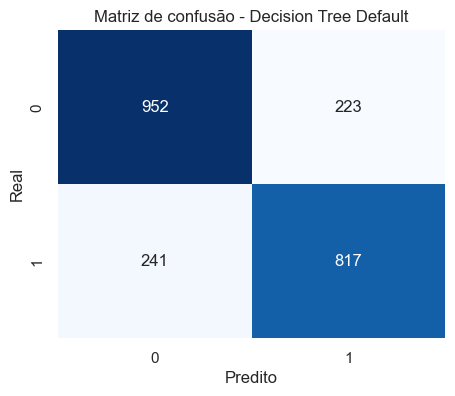

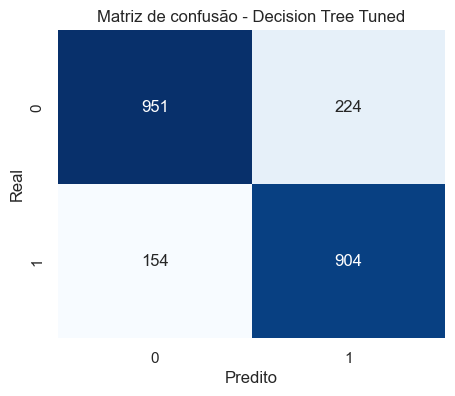

|--- num__duration <= 206.50
|   |--- cat__poutcome_success <= 0.50
|   |   |--- num__duration <= 77.50
|   |   |   |--- cat__month_feb <= 0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- cat__month_feb >  0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- num__duration >  77.50
|   |   |   |--- cat__contact_unknown <= 0.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- cat__contact_unknown >  0.50
|   |   |   |   |--- truncated branch of depth 5
|   |--- cat__poutcome_success >  0.50
|   |   |--- num__duration <= 119.50
|   |   |   |--- num__duration <= 79.50
|   |   |   |   |--- class: 0
|   |   |   |--- num__duration >  79.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- num__duration >  119.50
|   |   |   |--- num__age <= 66.00
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- num__age >  66.00
|   |   |   |   |--- class: 1
|--- num__duration >  206.50
|   |--- num__duration <= 472.50
|   |   

In [53]:
plot_confusion(decision_tree_artifact.confusion_matrix_test, decision_tree_artifact.name)
plot_confusion(decision_tree_tuned_artifact.confusion_matrix_test, decision_tree_tuned_artifact.name)
print(tree_rules_text)

A árvore default tende a superajustar. A versão otimizada reduz profundidade e restrições de folhas, melhorando generalização sem perder totalmente a interpretabilidade. As primeiras regras já são coerentes com o domínio: `duration` aparece no topo como proxy forte de engajamento, `poutcome_success` diferencia clientes com histórico positivo e `contact_unknown` sinaliza menor qualidade de informação.

## 8. Validação Cruzada e Busca de Hiperparâmetros

Foi usada `StratifiedKFold(n_splits=3, shuffle=True, random_state=42)`. A estratégia combinou `RandomizedSearchCV` amplo e `GridSearchCV` refinado para a árvore. A busca aleatória explora rapidamente combinações heterogêneas, enquanto a grade final refina a vizinhança do melhor ponto encontrado.

In [54]:
tree_model = {"best_params": decision_tree_tuned_artifact.best_params, "cv_summary": decision_tree_tuned_artifact.cv_summary}
tree_model["best_params"], tree_model["cv_summary"]

({'dt__class_weight': 'balanced',
  'dt__criterion': 'log_loss',
  'dt__max_depth': 13,
  'dt__max_features': None,
  'dt__min_samples_leaf': 10,
  'dt__min_samples_split': 2},
 {'random_search': {'best_score': 0.8153352562582131,
   'best_params': {'dt__min_samples_split': 2,
    'dt__min_samples_leaf': 10,
    'dt__max_features': None,
    'dt__max_depth': 15,
    'dt__criterion': 'log_loss',
    'dt__class_weight': 'balanced'},
   'top_results': [{'rank_test_score': 1,
     'mean_test_score': 0.8153352562582131,
     'std_test_score': 0.0029710153277358684,
     'params': {'dt__min_samples_split': 2,
      'dt__min_samples_leaf': 10,
      'dt__max_features': None,
      'dt__max_depth': 15,
      'dt__criterion': 'log_loss',
      'dt__class_weight': 'balanced'}},
    {'rank_test_score': 2,
     'mean_test_score': 0.8113114203674897,
     'std_test_score': 0.004081913331286194,
     'params': {'dt__min_samples_split': 20,
      'dt__min_samples_leaf': 2,
      'dt__max_features': N

In [55]:
display(Markdown("### Top resultados - RandomizedSearchCV"))
display(pd.DataFrame(tree_model["cv_summary"]["random_search"]["top_results"]))
display(Markdown("### Top resultados - GridSearchCV"))
pd.DataFrame(tree_model["cv_summary"]["grid_search"]["top_results"])

### Top resultados - RandomizedSearchCV

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.815335,0.002971,"{'dt__min_samples_split': 2, 'dt__min_samples_..."
1,2,0.811311,0.004082,"{'dt__min_samples_split': 20, 'dt__min_samples..."
2,3,0.806340,0.007735,"{'dt__min_samples_split': 2, 'dt__min_samples_..."
3,4,0.800809,0.011786,"{'dt__min_samples_split': 2, 'dt__min_samples_..."
4,5,0.792052,0.006203,"{'dt__min_samples_split': 10, 'dt__min_samples..."


### Top resultados - GridSearchCV

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.821974,0.000696,"{'dt__class_weight': 'balanced', 'dt__criterio..."
1,1,0.821974,0.000696,"{'dt__class_weight': 'balanced', 'dt__criterio..."
2,3,0.819610,0.001495,"{'dt__class_weight': 'balanced', 'dt__criterio..."
3,3,0.819610,0.001495,"{'dt__class_weight': 'balanced', 'dt__criterio..."
4,5,0.818325,0.006025,"{'dt__class_weight': 'balanced', 'dt__criterio..."


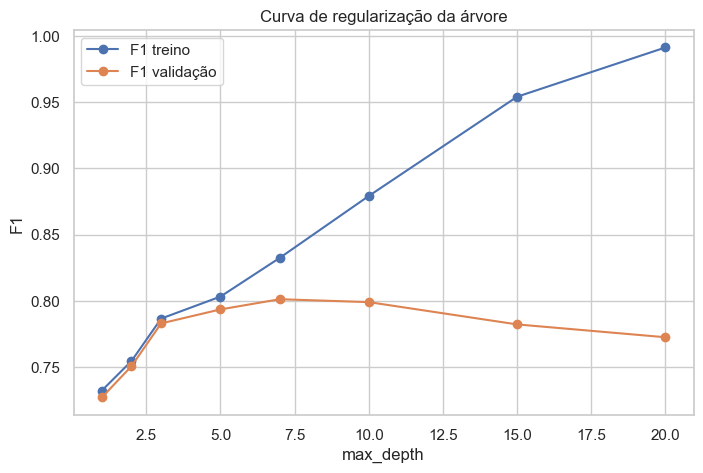

In [56]:
def plot_depth_curve(X_train: pd.DataFrame, y_train: pd.Series):
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    depths = [1, 2, 3, 5, 7, 10, 15, 20]
    train_scores = []
    val_scores = []
    for depth in depths:
        fold_train = []
        fold_val = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_fold_train = X_train.iloc[train_idx]
            X_fold_val = X_train.iloc[val_idx]
            y_fold_train = y_train.iloc[train_idx]
            y_fold_val = y_train.iloc[val_idx]
            pipeline = Pipeline([("preprocessor", build_preprocessor(scale_numeric=False)), ("dt", DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE))])
            pipeline.fit(X_fold_train, y_fold_train)
            fold_train.append(f1_score(y_fold_train, pipeline.predict(X_fold_train), zero_division=0))
            fold_val.append(f1_score(y_fold_val, pipeline.predict(X_fold_val), zero_division=0))
        train_scores.append(np.mean(fold_train))
        val_scores.append(np.mean(fold_val))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(depths, train_scores, marker="o", label="F1 treino")
    ax.plot(depths, val_scores, marker="o", label="F1 validação")
    ax.set_xlabel("max_depth")
    ax.set_ylabel("F1")
    ax.set_title("Curva de regularização da árvore")
    ax.legend()
    plt.show()

plot_depth_curve(X_train, y_train)

A curva de profundidade evidencia o trade-off de regularização: profundidades altas empurram o score de treino para cima, mas prejudicam a validação quando o modelo passa a memorizar ruído. Em árvores, não falamos em mínimos locais como em gradiente descendente; o treinamento usa escolhas gulosas de partição, o que reforça a importância de validação cruzada e tuning para controlar a estrutura final.

## 9. Modelos Avançados

Foram avaliados SVM, Random Forest, Gradient Boosting e um `VotingClassifier` combinando SVM, RF e Regressão Logística.

In [57]:
svm_search = RandomizedSearchCV(estimator=build_svm_pipeline(), param_distributions={"svc__kernel": ["linear", "rbf"], "svc__C": np.random.default_rng(RANDOM_STATE).uniform(0.01, 20, 200), "svc__class_weight": [None, "balanced"], "svc__gamma": ["scale", "auto"]}, n_iter=6, scoring="f1", cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE), random_state=RANDOM_STATE, n_jobs=1, refit=True)
svm_search.fit(X_train, y_train)
svm_artifact = fit_and_evaluate("SVM Tuned", svm_search.best_estimator_, X_train, X_test, y_train, y_test, best_params=svm_search.best_params_, cv_summary={"random_search": summarize_cv(svm_search)})

rf_search = RandomizedSearchCV(estimator=build_rf_pipeline(), param_distributions={"selector__k": [5, 10, 15, 20, "all"], "rf__n_estimators": [50, 100, 200], "rf__max_depth": [None, 5, 10, 20], "rf__min_samples_leaf": [1, 2, 5], "rf__class_weight": [None, "balanced"]}, n_iter=6, scoring="f1", cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE), random_state=RANDOM_STATE, n_jobs=1, refit=True)
rf_search.fit(X_train, y_train)
rf_artifact = fit_and_evaluate("Random Forest Tuned", rf_search.best_estimator_, X_train, X_test, y_train, y_test, best_params=rf_search.best_params_, cv_summary={"random_search": summarize_cv(rf_search)})

gb_search = RandomizedSearchCV(estimator=build_gradient_boosting_pipeline(), param_distributions={"selector__k": [5, 10, 15, 20, "all"], "gb__n_estimators": [50, 100, 200], "gb__learning_rate": np.random.default_rng(RANDOM_STATE + 7).uniform(0.01, 0.3, 500), "gb__subsample": [0.7, 0.85, 1.0], "gb__max_depth": [2, 3, 4], "gb__min_samples_leaf": [1, 5, 10]}, n_iter=6, scoring="f1", cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE), random_state=RANDOM_STATE, n_jobs=1, refit=True)
gb_search.fit(X_train, y_train)
gb_artifact = fit_and_evaluate("Gradient Boosting Tuned", gb_search.best_estimator_, X_train, X_test, y_train, y_test, best_params=gb_search.best_params_, cv_summary={"random_search": summarize_cv(gb_search)})

voting_artifact = fit_and_evaluate("Voting Ensemble", prepare_voting_classifier(svm_search.best_estimator_, rf_search.best_estimator_), X_train, X_test, y_train, y_test)
artifacts = [perceptron_artifact, decision_tree_artifact, decision_tree_tuned_artifact, svm_artifact, rf_artifact, gb_artifact, voting_artifact]
metrics_df = collect_model_rows(artifacts)
metrics_df.round(3)

,model,fit_seconds,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,train_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
5,Gradient Boosting Tuned,2.999,0.891,0.866,0.912,0.888,0.962,0.955,0.870,0.842,0.892,0.866,0.931,0.902
4,Random Forest Tuned,4.196,0.897,0.857,0.940,0.897,0.972,0.970,0.858,0.816,0.904,0.858,0.919,0.885
6,Voting Ensemble,6.151,0.879,0.841,0.918,0.878,0.881,0.899,0.855,0.815,0.897,0.854,0.857,0.881
3,SVM Tuned,2.022,0.877,0.836,0.921,0.876,0.938,0.911,0.853,0.814,0.893,0.852,0.922,0.893
2,Decision Tree Tuned,0.117,0.876,0.848,0.899,0.873,0.951,0.944,0.831,0.801,0.854,0.827,0.888,0.852
1,Decision Tree Default,0.209,1.000,1.000,1.000,1.000,1.000,1.000,0.792,0.786,0.772,0.779,0.791,0.833
0,Perceptron Baseline,0.122,0.758,0.765,0.706,0.734,0.842,0.790,0.749,0.749,0.708,0.728,0.830,0.777


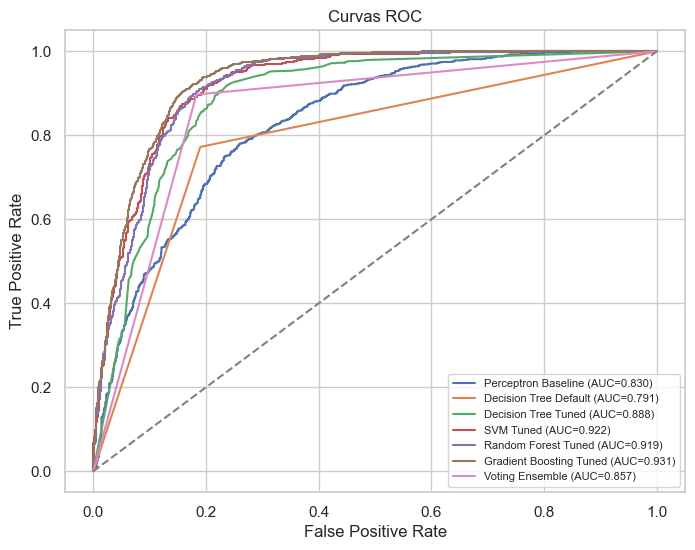

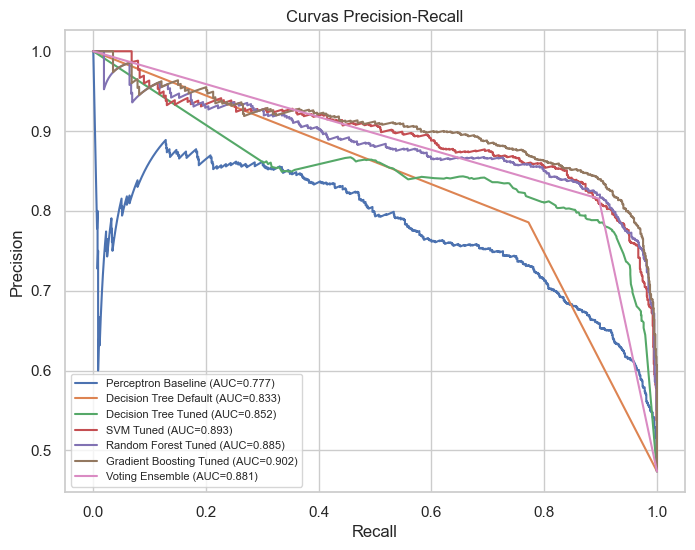

In [58]:
plot_model_curves(y_test, artifacts)

### Importancia de features: Random Forest Tuned

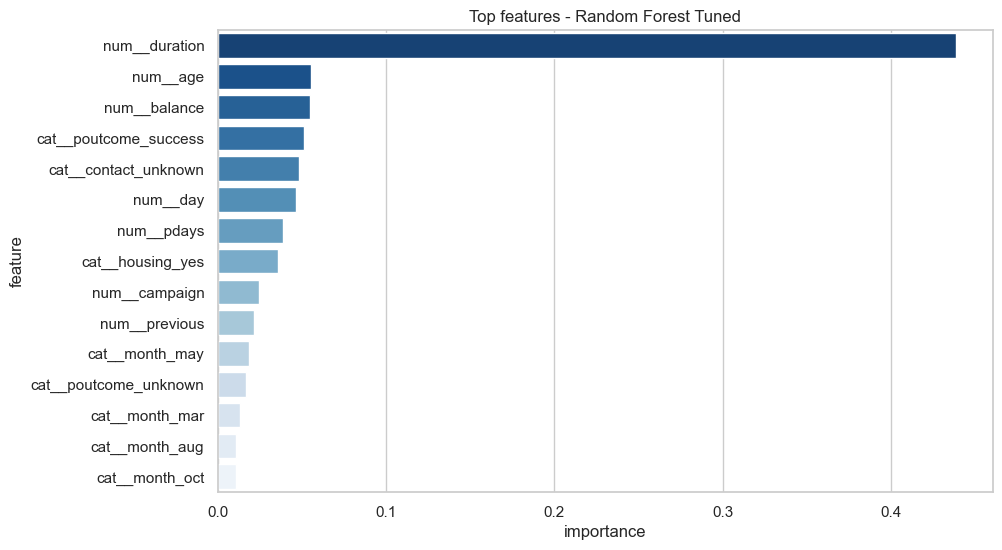

,feature,importance
3,num__duration,0.438218
0,num__age,0.055798
1,num__balance,0.054761
40,cat__poutcome_success,0.051091
27,cat__contact_unknown,0.048252
2,num__day,0.046867
5,num__pdays,0.038794
24,cat__housing_yes,0.035775
4,num__campaign,0.024840
6,num__previous,0.021865


### Importancia de features: Gradient Boosting Tuned

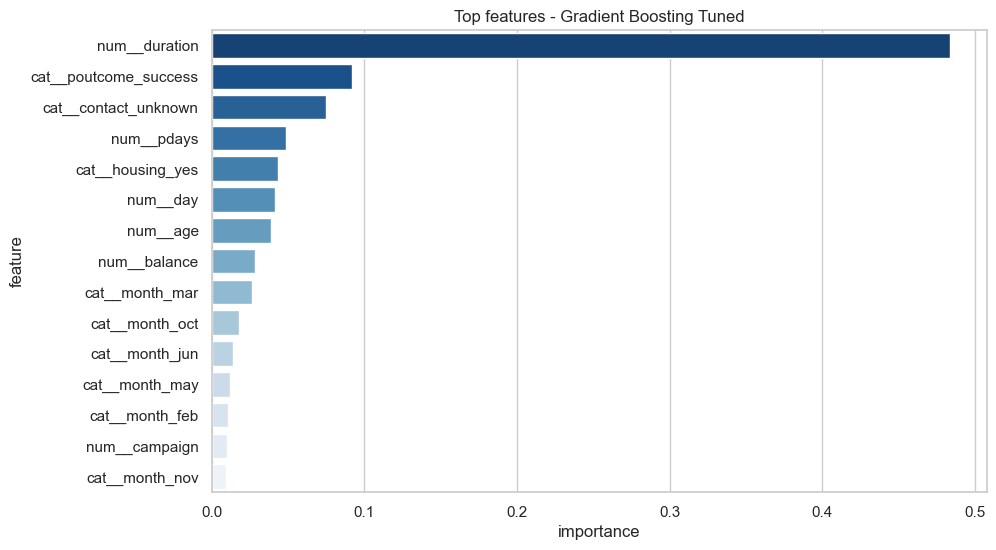

,feature,importance
3,num__duration,0.483608
40,cat__poutcome_success,0.092000
27,cat__contact_unknown,0.074519
5,num__pdays,0.048439
24,cat__housing_yes,0.043490
2,num__day,0.041593
0,num__age,0.038871
1,num__balance,0.028160
34,cat__month_mar,0.026572
37,cat__month_oct,0.018017


In [59]:
for artifact in [rf_artifact, gb_artifact]:
    display(Markdown(f"### Importancia de features: {artifact.name}"))
    display(plot_feature_importance(artifact, X_test, y_test))

SVM exige escalonamento e tem custo computacional mais alto, especialmente com kernels não lineares. Random Forest reduz variância por bagging. Gradient Boosting reduz viés de forma sequencial, mas exige tuning mais cuidadoso do `learning_rate`. O VotingClassifier explora complementaridade entre vieses diferentes.

## 10. Comparação Final e Discussão

In [60]:
metrics_df.round(3)

,model,fit_seconds,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,train_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
5,Gradient Boosting Tuned,2.999,0.891,0.866,0.912,0.888,0.962,0.955,0.870,0.842,0.892,0.866,0.931,0.902
4,Random Forest Tuned,4.196,0.897,0.857,0.940,0.897,0.972,0.970,0.858,0.816,0.904,0.858,0.919,0.885
6,Voting Ensemble,6.151,0.879,0.841,0.918,0.878,0.881,0.899,0.855,0.815,0.897,0.854,0.857,0.881
3,SVM Tuned,2.022,0.877,0.836,0.921,0.876,0.938,0.911,0.853,0.814,0.893,0.852,0.922,0.893
2,Decision Tree Tuned,0.117,0.876,0.848,0.899,0.873,0.951,0.944,0.831,0.801,0.854,0.827,0.888,0.852
1,Decision Tree Default,0.209,1.000,1.000,1.000,1.000,1.000,1.000,0.792,0.786,0.772,0.779,0.791,0.833
0,Perceptron Baseline,0.122,0.758,0.765,0.706,0.734,0.842,0.790,0.749,0.749,0.708,0.728,0.830,0.777


In [61]:
best_model = max(artifacts, key=lambda artifact: artifact.test_metrics["f1"])
print({"best_model": best_model.name, "f1": round(best_model.test_metrics["f1"], 3), "roc_auc": round(best_model.test_metrics["roc_auc"], 3), "pr_auc": round(best_model.test_metrics["pr_auc"], 3)})

{'best_model': 'Gradient Boosting Tuned', 'f1': 0.866, 'roc_auc': 0.931, 'pr_auc': 0.902}


Na decisão de implantação, não basta olhar apenas a melhor métrica. Um modelo um pouco pior, mas mais interpretável e barato, pode ser preferível em ambiente bancário regulado. Se o ganho do ensemble sobre a árvore otimizada for pequeno, a árvore ainda pode ser a melhor opção para explicabilidade.

## 11. Conclusão

O projeto mostra a progressão completa exigida: baseline linear, árvore, tuning com validação cruzada e modelos avançados. Melhorias futuras:
- repetir o estudo sem `duration` para evitar leakage operacional
- calibrar limiar de decisão conforme custo de FP/FN
- testar stacking e engenharia de features
- monitorar drift caso o modelo seja colocado em produção